In [1]:
#1. Import required libraries 
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt

In [2]:
# 2. Data analysis and preprocessing. Reuse preprocessing code from Part I.
df_wine_white = pd.read_csv('./noisy_datasets/wine_quality/winequality-white.csv', sep=';')
df_wine_red = pd.read_csv('./noisy_datasets/wine_quality/winequality-red.csv', sep=';')

df_wine_white['type'] = 'white'
df_wine_red['type'] = 'red'

df_wine = pd.concat([df_wine_white, df_wine_red])
df_wine_preprocessed = df_wine.copy()
df_wine_preprocessed['type'] = df_wine_preprocessed['type'].astype('category')
df_wine_preprocessed = pd.get_dummies(df_wine_preprocessed, drop_first=False)
bool_columns = df_wine_preprocessed.select_dtypes(include=['bool'])
for col in bool_columns:
    df_wine_preprocessed[col] = df_wine_preprocessed[col].astype('int')
df_wine_preprocessed = df_wine_preprocessed.drop(columns=['fixed acidity', 'volatile acidity', 'citric acid', 'sulphates', 'type_red', 'type_white'])

In [3]:
# 3. Data preparation (y:density)
warnings.filterwarnings('ignore')
df_wine_shuffled = df_wine_preprocessed.sample(frac=1).reset_index(drop=True)
split_index = int(0.8 * len(df_wine_shuffled))

X = df_wine_shuffled.drop(columns=['alcohol'])
y = df_wine_shuffled['alcohol']

X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(5197, 7) (5197,) (1300, 7) (1300,)


In [4]:
# 4. Linear Regression using OLS
def ols(X, y):
    return np.dot(np.linalg.inv(X.T @ X) @ X.T, y)

def predict(w, X):
    return np.dot(X, w)

def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

In [5]:
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
weights = ols(X_train, y_train)

In [6]:
weights = np.array(weights, dtype=float)
pred_ols = predict(weights, X_test)

In [7]:
mse_ols = mse(y_test, pred_ols)
print(mse_ols)

0.524182186867553


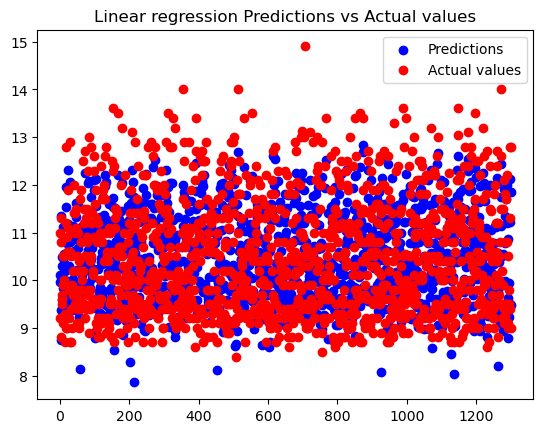

In [8]:
n = y_test.shape[0]
plt.scatter([x for x in range(1, n+1)], pred_ols, color='blue', label='Predictions')
plt.scatter([x for x in range(1, n+1)], y_test, color='red', label='Actual values')

plt.title('Linear regression Predictions vs Actual values')
plt.legend()
plt.show()

In [9]:
# 5. Ridge Regression using OLS
def ridge_weights(X, y, lambda_):
    n, m = X.shape
    I = np.eye(m)
    return np.linalg.inv(X.T @ X + lambda_ * I) @ X.T @ y

In [10]:
lambda_ = 10000.0
r_weights = ridge_weights(X_train, y_train, lambda_)
r_weights = np.array(r_weights, dtype=float)

In [11]:
pred_ridge = predict(r_weights, X_test)

In [12]:
mse_ridge = mse(y_test, pred_ridge)
print(mse_ridge)

2.0087664892221033


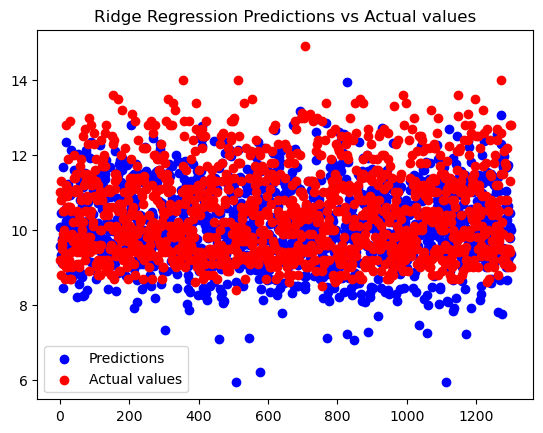

In [13]:
n = y_test.shape[0]
plt.scatter([x for x in range(1, n+1)], pred_ridge, color='blue', label='Predictions')
plt.scatter([x for x in range(1, n+1)], y_test, color='red', label='Actual values')

plt.title('Ridge Regression Predictions vs Actual values')
plt.legend()
plt.show()

In [14]:
weights_dic = {'ols': weights, 'ridge': r_weights}
print(weights_dic)
with open('heejuhwa_assignment1_part3.pickle', 'wb') as file:
    pickle.dump(weights_dic, file)

{'ols': array([ 3.04155449e+02,  6.79730215e-02, -4.00682288e-01, -3.06239401e-03,
       -6.42741624e-03, -2.99279257e+02,  8.90185190e-01,  2.84800671e-01]), 'ridge': array([ 0.21416637, -0.04477901,  0.01248264,  0.00353596,  0.01157885,
        0.21235024,  0.69971509,  1.06709338])}


Reference

* preprocessing code from Part I
* data split code from Part II
* https://numpy.org/doc/stable/reference/generated/numpy.matrix.transpose.html
* https://numpy.org/doc/stable/reference/routines.linalg.html#module-numpy.linalg
* https://docs.python.org/3/library/pickle.html
*   